In [116]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator

base_path = Path.cwd()

data_path = base_path / 'Data' / 'Datasheet.xlsx'
img_path = base_path.parent.parent / '31' / 'Images'

Data50Tab = pd.read_excel(data_path, sheet_name='T = 50°C',engine='openpyxl')
Data48Tab = pd.read_excel(data_path, sheet_name='T = 48°C',engine='openpyxl')
Data45Tab = pd.read_excel(data_path, sheet_name='T = 45 °C',engine='openpyxl')
Data42Tab = pd.read_excel(data_path, sheet_name='T = 42°C',engine='openpyxl')
Data40Tab = pd.read_excel(data_path, sheet_name='T = 40°C',engine='openpyxl')
Data35Tab = pd.read_excel(data_path, sheet_name='T = 35°C',engine='openpyxl')
Data30Tab = pd.read_excel(data_path, sheet_name='T = 30 °C',engine='openpyxl')

Data30 = np.array([[x,y] for x,y in zip(Data30Tab['Druck [10^5 Pa]'].tolist(), Data30Tab['Volumen [ml]'].tolist())])
Data35 = np.array([[x,y] for x,y in zip(Data35Tab['Druck [10^5 Pa]'].tolist(), Data35Tab['Volumen [ml]'].tolist())])
Data40 = np.array([[x,y] for x,y in zip(Data40Tab['Druck [10^5 Pa]'].tolist(), Data40Tab['Volumen [ml]'].tolist())])
Data42 = np.array([[x,y] for x,y in zip(Data42Tab['Druck [10^5 Pa]'].tolist(), Data42Tab['Volumen [ml]'].tolist())])
Data45 = np.array([[x,y] for x,y in zip(Data45Tab['Druck [10^5 Pa]'].tolist(), Data45Tab['Volumen [ml]'].tolist())])
Data48 = np.array([[x,y] for x,y in zip(Data48Tab['Druck [10^5 Pa]'].tolist(), Data48Tab['Volumen [ml]'].tolist())])
Data50 = np.array([[x,y] for x,y in zip(Data50Tab['Druck [10^5 Pa]'].tolist(), Data50Tab['Volumen [ml]'].tolist())])


In [ ]:
def pVPlot(T, Data, vdw=True, hert=0, ylim=30, xlim=4):
    plt.errorbar(Data[:,1], Data[:,0], fmt='x', label=f'T = {T} °C', xerr=0.025, yerr=0.03, color='black')
    if vdw:
        plt.hlines(y=hert, color='red', linestyle='--', xmin=-1, xmax=5, linewidth=0.8, label='Maxwell')
    plt.xlabel('Volumen [ml]')
    plt.ylabel('Druck [10$^5$ Pa]')
    plt.title(f'p V Relation bei {T}°C', loc='left')
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
    plt.xticks(np.arange(0, xlim+1, 0.5))
    plt.yticks(np.arange(0, ylim+1, 5))
    plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
    plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
    plt.xlim(0, xlim)
    plt.ylim(0, ylim)
    plt.legend()
    plt.savefig(img_path / 'pV' /f'pV_T{T}.png', bbox_inches='tight')

## Plots

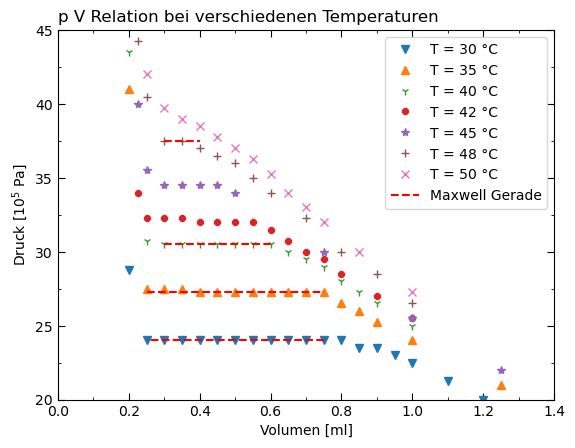

In [162]:
plt.plot(Data30[:,1], Data30[:,0], 'v', label='T = 30 °C')
plt.hlines(y=24, color='red', linestyle='--', xmin=0.75, xmax=0.25, linewidth=1.5)
plt.plot(Data35[:,1], Data35[:,0], '^', label='T = 35 °C')
plt.hlines(y=27.25, color='red', linestyle='--', xmin=0.25, xmax=0.75, linewidth=1.5)
plt.plot(Data40[:,1], Data40[:,0], '1', label='T = 40 °C')
plt.hlines(y=30.5, color='red', linestyle='--', xmin=0.3, xmax=0.6, linewidth=1.5)
plt.plot(Data42[:,1], Data42[:,0], '8', label='T = 42 °C', markersize=4)
plt.plot(Data45[:,1], Data45[:,0], '*', label='T = 45 °C')
plt.plot(Data48[:,1], Data48[:,0], '+', label='T = 48 °C')
plt.plot(Data50[:,1], Data50[:,0], 'x', label='T = 50 °C')
plt.hlines(y=37.5, color='red', linestyle='--', xmin=0.3, xmax=0.4, linewidth=1.5, label='Maxwell Gerade')
plt.xlabel('Volumen [ml]')
plt.ylabel('Druck [10$^5$ Pa]')
plt.title('p V Relation bei verschiedenen Temperaturen', loc='left')
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(0, 5, 0.2))
plt.yticks(np.arange(0, 60, 5))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
plt.xlim(0, 1.4)
plt.ylim(20, 45)
plt.legend()
plt.savefig(img_path / 'pV_all.png', bbox_inches='tight')